## Dogs vs. Cats Classification

Select free T4 GPU in Runtime settings

## Download data

In [ ]:
!pip install -q gdown
!gdown https://drive.google.com/uc?id=12WhCCpKTWpeBztLegcoYx2gMo2KbaxDG

Downloading...
From (original): https://drive.google.com/uc?id=12WhCCpKTWpeBztLegcoYx2gMo2KbaxDG
From (redirected): https://drive.google.com/uc?id=12WhCCpKTWpeBztLegcoYx2gMo2KbaxDG&confirm=t&uuid=30af4165-050a-48d5-891d-4c7dc05a1ff6
To: /content/dogs-vs-cats.zip
100% 852M/852M [00:03<00:00, 238MB/s]


In [ ]:
import zipfile

with zipfile.ZipFile('dogs-vs-cats.zip', 'r') as zip_file:
    zip_file.extractall('data')

with zipfile.ZipFile('data/train.zip', 'r') as zip_file:
    zip_file.extractall('data/')

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Paths
base_dir = 'data/train'
train_dir = 'data/train_split'
val_dir = 'data/val_split'

# Create directories
os.makedirs(os.path.join(train_dir, 'dogs'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'cats'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'dogs'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'cats'), exist_ok=True)

# Split data
filenames = os.listdir(base_dir)
train_files, val_files = train_test_split(filenames, test_size=0.2, random_state=42)

for file in train_files:
    if 'dog' in file:
        shutil.move(os.path.join(base_dir, file), os.path.join(train_dir, 'dogs', file))
    elif 'cat' in file:
        shutil.move(os.path.join(base_dir, file), os.path.join(train_dir, 'cats', file))

for file in val_files:
    if 'dog' in file:
        shutil.move(os.path.join(base_dir, file), os.path.join(val_dir, 'dogs', file))
    elif 'cat' in file:
        shutil.move(os.path.join(base_dir, file), os.path.join(val_dir, 'cats', file))

## Create data generators

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


## Create basic CNN classification model

In [ ]:
from tensorflow.keras import models, layers

# Build the model
model_basic = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_basic.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Train basic model

In [ ]:
history_model_basic = model_basic.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.5729 - loss: 0.6865 - val_accuracy: 0.7254 - val_loss: 0.5431
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.7621 - loss: 0.4874 - val_accuracy: 0.7862 - val_loss: 0.4630
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - accuracy: 0.8195 - loss: 0.3957 - val_accuracy: 0.8204 - val_loss: 0.4025
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.8653 - loss: 0.3064 - val_accuracy: 0.7978 - val_loss: 0.5474
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.9161 - loss: 0.2057 - val_accuracy: 0.8262 - val_loss: 0.4260
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.9649 - loss: 0.0987 - val_accuracy: 0.8278 - val_loss: 0.6149
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.9846 - loss: 0.0486 - val_accuracy: 0.8234 - val_loss: 0.6686
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9892 - loss: 0.0327 - val_accurac

## Plot accuracy and loss

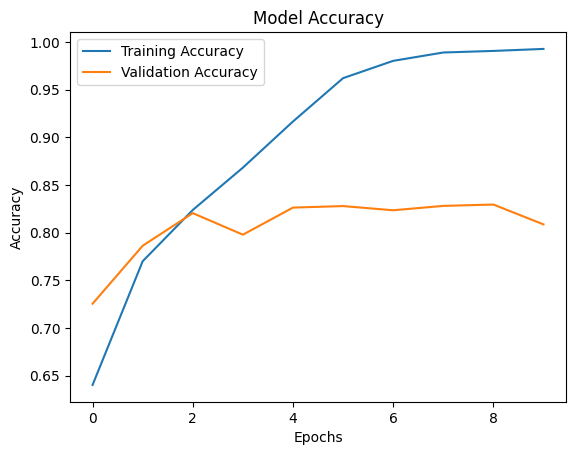

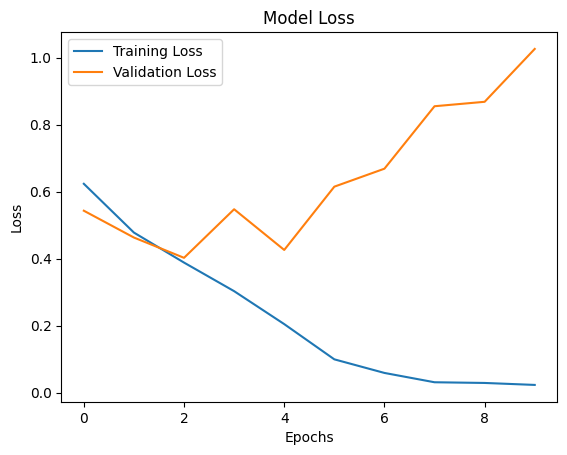

In [ ]:
plt.plot(history_model_basic.history['accuracy'], label='Training Accuracy')
plt.plot(history_model_basic.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_model_basic.history['loss'], label='Training Loss')
plt.plot(history_model_basic.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step


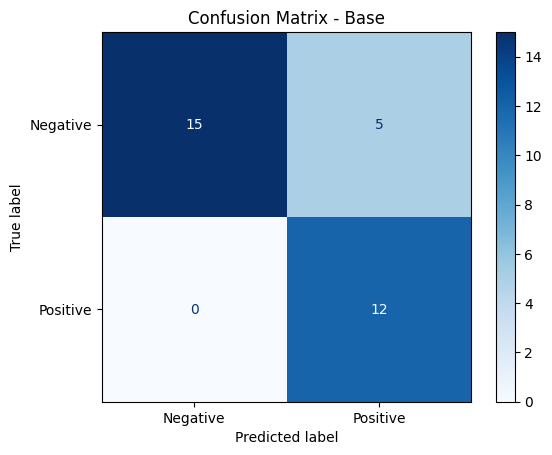


Base Model:
True Positives: 12
False Positives: 5
True Negatives: 15
False Negatives: 0
Accuracy: 0.84
Precision: 0.71
Recall: 1.00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load your saved models (you'll need to replace these with your actual models)
models = {
    'Base': model_basic,
    'Drop Out':model_dropout,
    'L2 Regularization':model_l2,
    'Early Stopping':model_earlystopping,
    'Data Augmentation':model_basic_aug
}


# Get validation data and labels
val_images, val_labels = next((x for x in val_generator))

# For each model
for model_name, model in models.items():
    # Make predictions
    predictions = model.predict(val_images)
    predicted_classes = (predictions > 0.5).astype("int32")

    # Generate confusion matrix
    cm = confusion_matrix(val_labels, predicted_classes)

    # Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # Print metrics
    tn, fp, fn, tp = cm.ravel()
    print(f'\n{model_name} Model:')
    print(f'True Positives: {tp}')
    print(f'False Positives: {fp}')
    print(f'True Negatives: {tn}')
    print(f'False Negatives: {fn}')
    print(f'Accuracy: {(tp+tn)/(tp+tn+fp+fn):.2f}')
    print(f'Precision: {tp/(tp+fp):.2f}' if (tp+fp) > 0 else 'Precision: N/A')
    print(f'Recall: {tp/(tp+fn):.2f}' if (tp+fn) > 0 else 'Recall: N/A')

## Add regularization

Add different regularization methods as described in the lab instructions and evaluate results.

### Add Dropout

all Layer dropout 50


In [ ]:
from tensorflow.keras import models, layers

# Build the model
model_dropout = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.50),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.50),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.50),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.50),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_model_dropout = model_dropout.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.5165 - loss: 0.7272 - val_accuracy: 0.6612 - val_loss: 0.6139
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.6707 - loss: 0.6019 - val_accuracy: 0.7184 - val_loss: 0.5502
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.7197 - loss: 0.5412 - val_accuracy: 0.7402 - val_loss: 0.5349
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.7532 - loss: 0.5037 - val_accuracy: 0.7168 - val_loss: 0.5454
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.7693 - loss: 0.4863 - val_accuracy: 0.7114 - val_loss: 0.5591
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.7945 - loss: 0.4490 - val_accuracy: 0.7746 - val_loss: 0.4657
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7959 - loss: 0.4328 - val_accuracy: 0.7790 - val_loss: 0.4507
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8140 - loss: 0.4076 - 

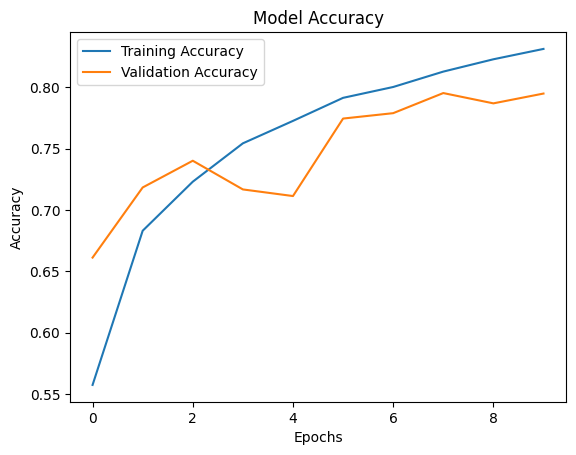

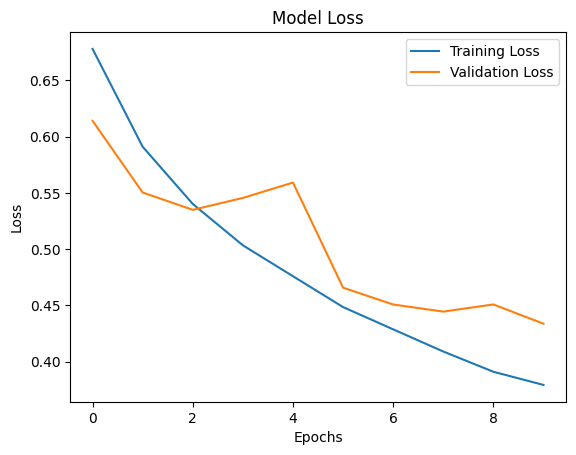

In [ ]:
plt.plot(history_model_dropout.history['accuracy'], label='Training Accuracy')
plt.plot(history_model_dropout.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_model_dropout.history['loss'], label='Training Loss')
plt.plot(history_model_dropout.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


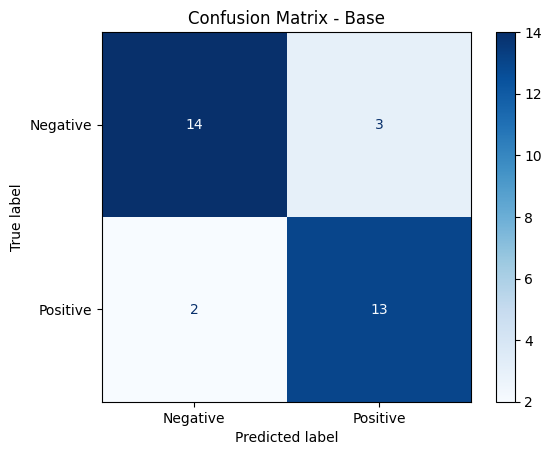


Base Model:
True Positives: 13
False Positives: 3
True Negatives: 14
False Negatives: 2
Accuracy: 0.84
Precision: 0.81
Recall: 0.87
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step


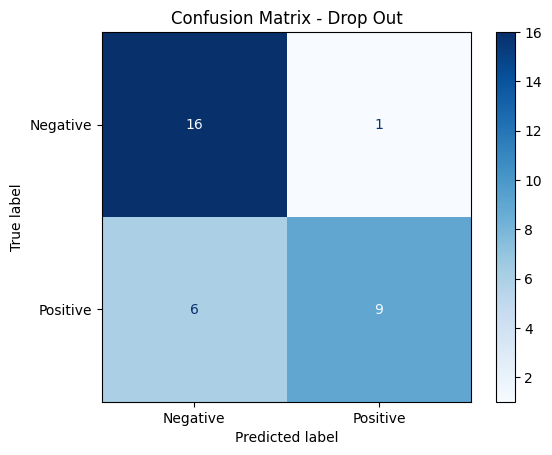


Drop Out Model:
True Positives: 9
False Positives: 1
True Negatives: 16
False Negatives: 6
Accuracy: 0.78
Precision: 0.90
Recall: 0.60


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load your saved models (you'll need to replace these with your actual models)
models = {
    'Base': model_basic,
    'Drop Out':model_dropout,
    # 'L2 Regularization':model_l2,
    # 'Early Stopping':model_earlystopping,
    # 'Data Augmentation':model_basic_aug
}


# Get validation data and labels
val_images, val_labels = next((x for x in val_generator))

# For each model
for model_name, model in models.items():
    # Make predictions
    predictions = model.predict(val_images)
    predicted_classes = (predictions > 0.5).astype("int32")

    # Generate confusion matrix
    cm = confusion_matrix(val_labels, predicted_classes)

    # Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # Print metrics
    tn, fp, fn, tp = cm.ravel()
    print(f'\n{model_name} Model:')
    print(f'True Positives: {tp}')
    print(f'False Positives: {fp}')
    print(f'True Negatives: {tn}')
    print(f'False Negatives: {fn}')
    print(f'Accuracy: {(tp+tn)/(tp+tn+fp+fn):.2f}')
    print(f'Precision: {tp/(tp+fp):.2f}' if (tp+fp) > 0 else 'Precision: N/A')
    print(f'Recall: {tp/(tp+fn):.2f}' if (tp+fn) > 0 else 'Recall: N/A')


L2 Regularization

In [ ]:
from tensorflow.keras import models, layers, regularizers

# Build the model with L2 regularization
model_l2 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_l2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:

# Train the model
history_model_l2 = model_l2.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 74ms/step - accuracy: 0.5565 - loss: 0.7857 - val_accuracy: 0.6864 - val_loss: 0.6214
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7002 - loss: 0.6070 - val_accuracy: 0.7058 - val_loss: 0.5901
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.7336 - loss: 0.5639 - val_accuracy: 0.6900 - val_loss: 0.6085
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.7494 - loss: 0.5435 - val_accuracy: 0.7674 - val_loss: 0.5237
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.7755 - loss: 0.5092 - val_accuracy: 0.7732 - val_loss: 0.5084
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7889 - loss: 0.4874 - val_accuracy: 0.7726 - val_loss: 0.5267
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.8016 - loss: 0.4760 - val_accuracy: 0.7942 - val_loss: 0.4851
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.8046 - loss: 0.4668 - 

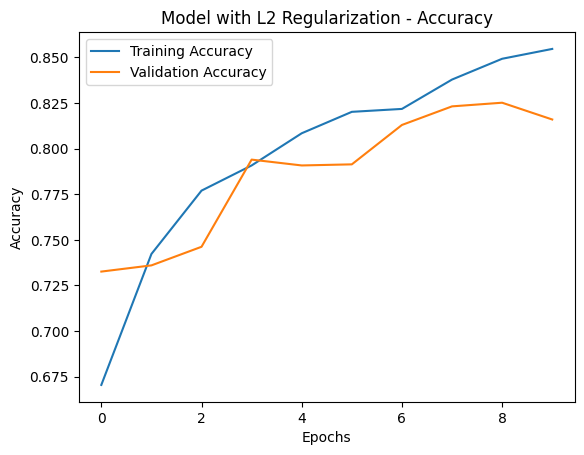

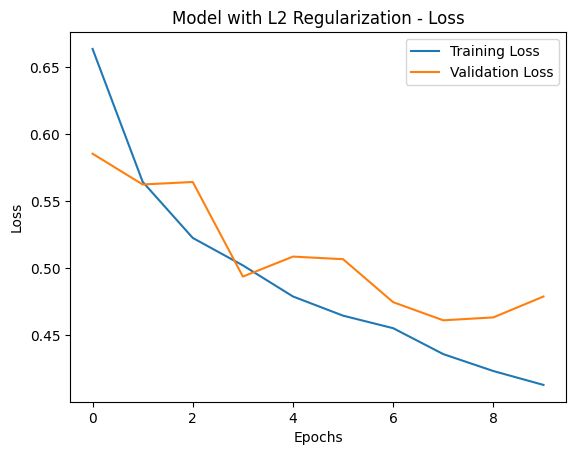

In [ ]:

# Plot results (same as before)
plt.plot(history_model_l2.history['accuracy'], label='Training Accuracy')
plt.plot(history_model_l2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with L2 Regularization - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_model_l2.history['loss'], label='Training Loss')
plt.plot(history_model_l2.history['val_loss'], label='Validation Loss')
plt.title('Model with L2 Regularization - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


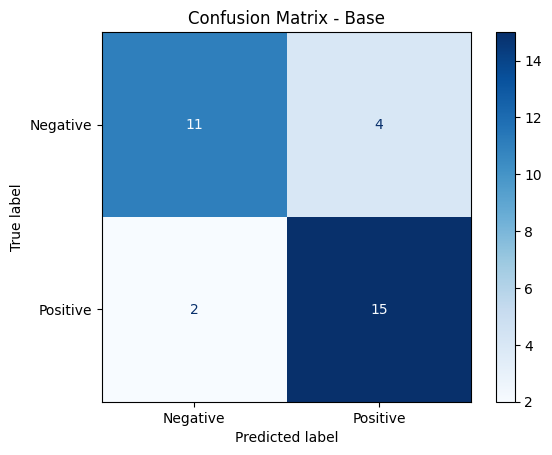


Base Model:
True Positives: 15
False Positives: 4
True Negatives: 11
False Negatives: 2
Accuracy: 0.81
Precision: 0.79
Recall: 0.88
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


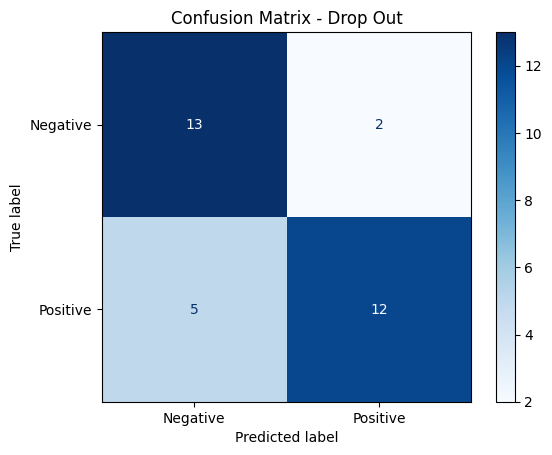


Drop Out Model:
True Positives: 12
False Positives: 2
True Negatives: 13
False Negatives: 5
Accuracy: 0.78
Precision: 0.86
Recall: 0.71
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


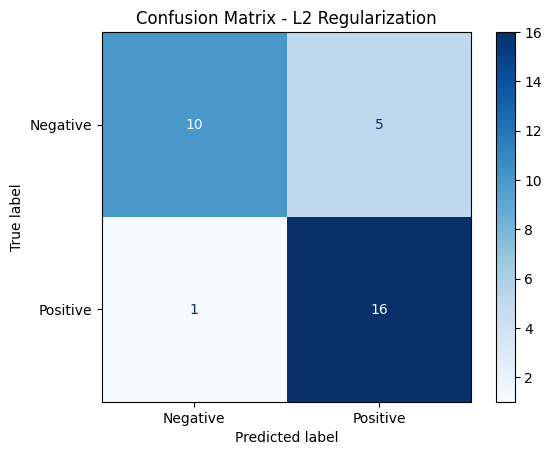


L2 Regularization Model:
True Positives: 16
False Positives: 5
True Negatives: 10
False Negatives: 1
Accuracy: 0.81
Precision: 0.76
Recall: 0.94


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load your saved models (you'll need to replace these with your actual models)
models = {
    'Base': model_basic,
    'Drop Out':model_dropout,
    'L2 Regularization':model_l2,
    # 'Early Stopping':model_earlystopping,
    # 'Data Augmentation':model_basic_aug
}


# Get validation data and labels
val_images, val_labels = next((x for x in val_generator))

# For each model
for model_name, model in models.items():
    # Make predictions
    predictions = model.predict(val_images)
    predicted_classes = (predictions > 0.5).astype("int32")

    # Generate confusion matrix
    cm = confusion_matrix(val_labels, predicted_classes)

    # Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # Print metrics
    tn, fp, fn, tp = cm.ravel()
    print(f'\n{model_name} Model:')
    print(f'True Positives: {tp}')
    print(f'False Positives: {fp}')
    print(f'True Negatives: {tn}')
    print(f'False Negatives: {fn}')
    print(f'Accuracy: {(tp+tn)/(tp+tn+fp+fn):.2f}')
    print(f'Precision: {tp/(tp+fp):.2f}' if (tp+fp) > 0 else 'Precision: N/A')
    print(f'Recall: {tp/(tp+fn):.2f}' if (tp+fn) > 0 else 'Recall: N/A')

Combine Dropuout with 30 and L2 with Lambda 0.001

In [ ]:
from tensorflow.keras import models, layers, regularizers

# Build the model with Dropout + L2
model_dropout_l2 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),  # Dropout after pooling

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),  # Dropout after pooling

    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),  # Dropout after pooling

    # Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),  # Dropout before output
    layers.Dense(1, activation='sigmoid')  # No regularization on output layer
])

# Compile the model dropout and L2
model_dropout_l2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:

# Train the model
history_dropout_l2 = model_dropout_l2.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.5712 - loss: 0.9197 - val_accuracy: 0.6886 - val_loss: 0.6498
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.6943 - loss: 0.6416 - val_accuracy: 0.7170 - val_loss: 0.5962
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7218 - loss: 0.5994 - val_accuracy: 0.7580 - val_loss: 0.5593
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.7368 - loss: 0.5805 - val_accuracy: 0.7700 - val_loss: 0.5416
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.7649 - loss: 0.5504 - val_accuracy: 0.7590 - val_loss: 0.5592
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.7753 - loss: 0.5356 - val_accuracy: 0.7860 - val_loss: 0.5240
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.7783 - loss: 0.5294 - val_accuracy: 0.7762 - val_loss: 0.5279
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7956 - loss: 0.5050 - 

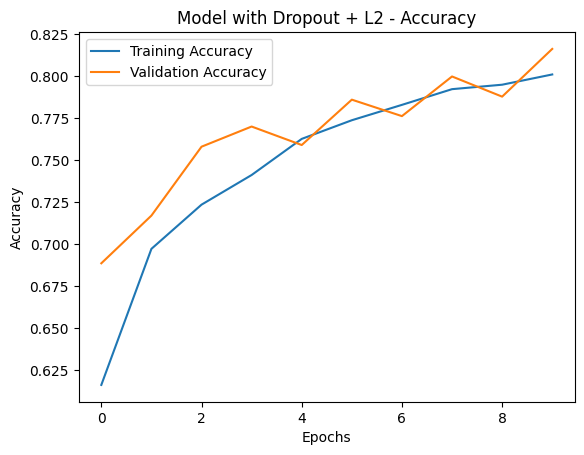

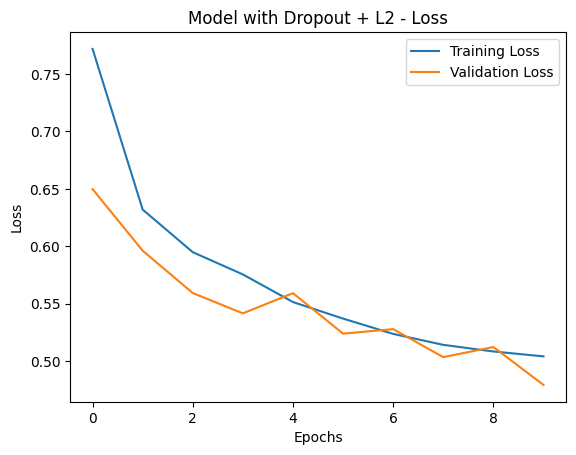

In [ ]:

# Plot results
plt.plot(history_dropout_l2.history['accuracy'], label='Training Accuracy')
plt.plot(history_dropout_l2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with Dropout + L2 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_dropout_l2.history['loss'], label='Training Loss')
plt.plot(history_dropout_l2.history['val_loss'], label='Validation Loss')
plt.title('Model with Dropout + L2 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Early Stopping


In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping

# Basic CNN model (original)
model_earlystopping = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_earlystopping.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Define EarlyStopping callback
early_stopping = EarlyStopping(  # Corrected: Use the EarlyStopping class directly
    monitor='val_loss',  # Monitor validation loss
    patience=3,         # Stop after 3 epochs without improvement
    restore_best_weights=True  # Restore the best model weights
)

In [ ]:
# Train the model with EarlyStopping
history_early_stopping = model_earlystopping.fit(  # Call fit() on the model, not the callback
    train_generator,
    epochs=10,          # Set a high max epoch (EarlyStopping will stop early)
    validation_data=val_generator,
    callbacks=[early_stopping]  # Pass the EarlyStopping callback here
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 67ms/step - accuracy: 0.6014 - loss: 0.6617 - val_accuracy: 0.7322 - val_loss: 0.5325
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7617 - loss: 0.4873 - val_accuracy: 0.7838 - val_loss: 0.4598
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.8118 - loss: 0.4099 - val_accuracy: 0.7956 - val_loss: 0.4484
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.8548 - loss: 0.3327 - val_accuracy: 0.8192 - val_loss: 0.4153
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.9028 - loss: 0.2369 - val_accuracy: 0.8190 - val_loss: 0.4924
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9433 - loss: 0.1508 - val_accuracy: 0.8160 - val_loss: 0.5547
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.9711 - loss: 0.0770 - val_accuracy: 0.8000 - val_loss: 0.7341


In [ ]:

# Plot results
plt.plot(history_basic.history['accuracy'], label='Training Accuracy')
plt.plot(history_basic.history['val_accuracy'], label='Validation Accuracy')
plt.title('Basic Model + EarlyStopping - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_early_stopping.history['loss'], label='Training Loss')
plt.plot(history_early_stopping.history['val_loss'], label='Validation Loss')
plt.title('Basic Model + EarlyStopping - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Print the number of epochs used
print(f"Training stopped at epoch {len(history_early_stopping.history['loss'])}")

NameError: name 'history_basic' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


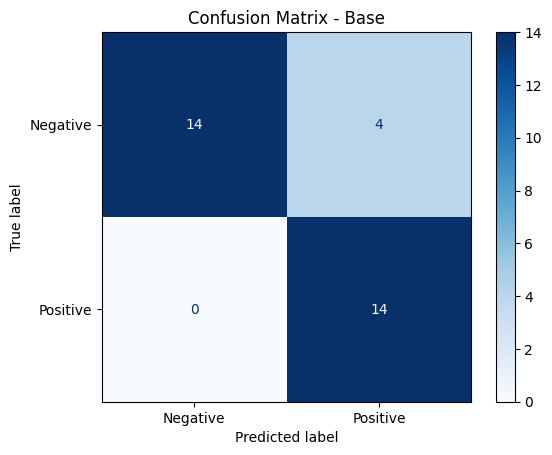


Base Model:
True Positives: 14
False Positives: 4
True Negatives: 14
False Negatives: 0
Accuracy: 0.88
Precision: 0.78
Recall: 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


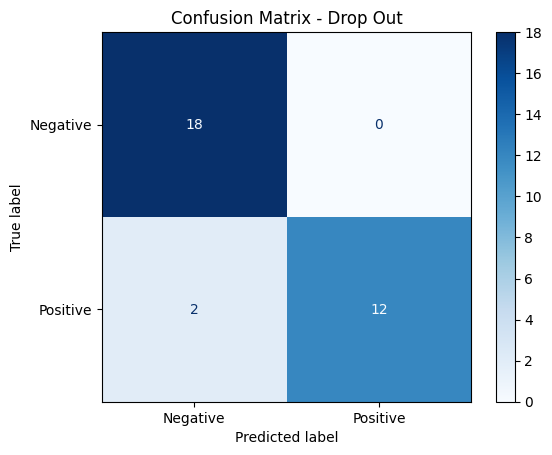


Drop Out Model:
True Positives: 12
False Positives: 0
True Negatives: 18
False Negatives: 2
Accuracy: 0.94
Precision: 1.00
Recall: 0.86
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


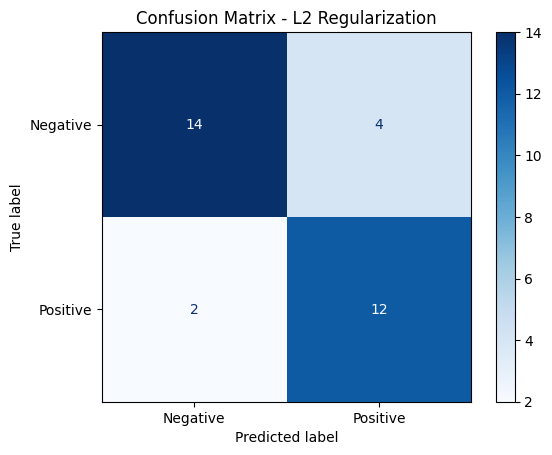


L2 Regularization Model:
True Positives: 12
False Positives: 4
True Negatives: 14
False Negatives: 2
Accuracy: 0.81
Precision: 0.75
Recall: 0.86
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 615ms/step


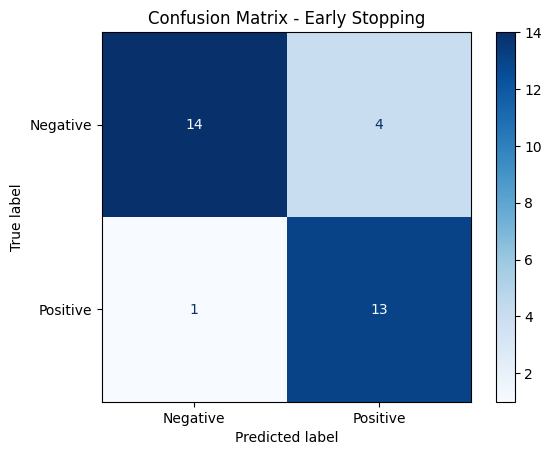


Early Stopping Model:
True Positives: 13
False Positives: 4
True Negatives: 14
False Negatives: 1
Accuracy: 0.84
Precision: 0.76
Recall: 0.93


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load your saved models (you'll need to replace these with your actual models)
models = {
    'Base': model_basic,
    'Drop Out':model_dropout,
    'L2 Regularization':model_l2,
    'Early Stopping':model_earlystopping,
    # 'Data Augmentation':model_basic_aug
}


# Get validation data and labels
val_images, val_labels = next((x for x in val_generator))

# For each model
for model_name, model in models.items():
    # Make predictions
    predictions = model.predict(val_images)
    predicted_classes = (predictions > 0.5).astype("int32")

    # Generate confusion matrix
    cm = confusion_matrix(val_labels, predicted_classes)

    # Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # Print metrics
    tn, fp, fn, tp = cm.ravel()
    print(f'\n{model_name} Model:')
    print(f'True Positives: {tp}')
    print(f'False Positives: {fp}')
    print(f'True Negatives: {tn}')
    print(f'False Negatives: {fn}')
    print(f'Accuracy: {(tp+tn)/(tp+tn+fp+fn):.2f}')
    print(f'Precision: {tp/(tp+fp):.2f}' if (tp+fp) > 0 else 'Precision: N/A')
    print(f'Recall: {tp/(tp+fn):.2f}' if (tp+fn) > 0 else 'Recall: N/A')

Data Agmentation

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 221ms/step - accuracy: 0.5284 - loss: 0.6931 - val_accuracy: 0.5498 - val_loss: 0.6889
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 135s 217ms/step - accuracy: 0.6125 - loss: 0.6506 - val_accuracy: 0.7226 - val_loss: 0.5470
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 212ms/step - accuracy: 0.6831 - loss: 0.5947 - val_accuracy: 0.7540 - val_loss: 0.5031
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 210ms/step - accuracy: 0.7161 - loss: 0.5469 - val_accuracy: 0.7772 - val_loss: 0.4681
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 210ms/step - accuracy: 0.7569 - loss: 0.5042 - val_accuracy: 0.7724 - val_loss: 0.4710
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 211ms/step - accuracy: 0.7599 - loss: 0.4929 - val_accuracy: 0.7890 - val_loss: 0.4461
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 215ms/step - accuracy: 0.7803 - loss: 0.4685 - val_accuracy: 0.8298 - val_loss: 0.3843
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 208ms/step - accuracy: 0.7927 -

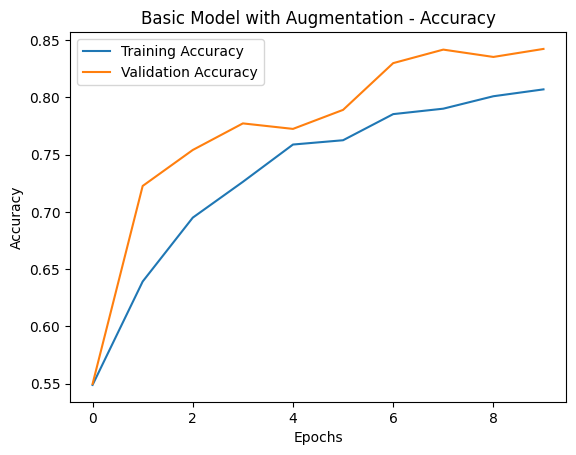

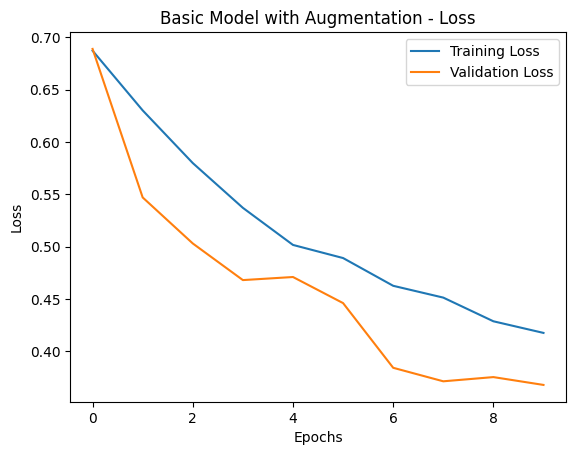

In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmented data generator for training
train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Validation data should NOT be augmented (only rescaled)
val_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator_augmented = train_datagen_augmented.flow_from_directory(
    train_dir,               # Your training directory
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,          # Your validation directory
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Basic CNN model
model_basic_aug = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model_basic_aug.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train with augmented data
history_basic_aug = model_basic_aug.fit(
    train_generator_augmented,
    epochs=10,  # You can adjust number of epochs
    validation_data=val_generator
)

# Plot results
plt.plot(history_basic_aug.history['accuracy'], label='Training Accuracy')
plt.plot(history_basic_aug.history['val_accuracy'], label='Validation Accuracy')
plt.title('Basic Model with Augmentation - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_basic_aug.history['loss'], label='Training Loss')
plt.plot(history_basic_aug.history['val_loss'], label='Validation Loss')
plt.title('Basic Model with Augmentation - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


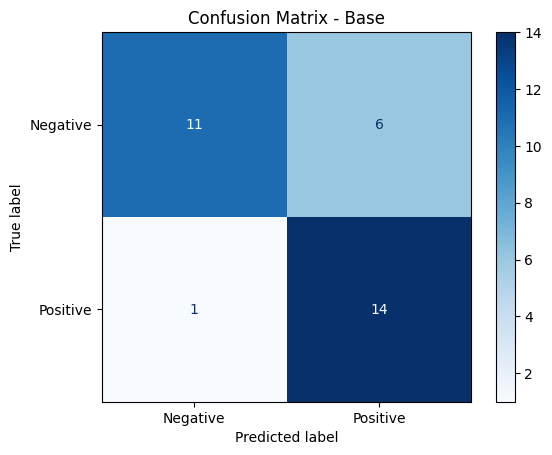


Base Model:
True Positives: 14
False Positives: 6
True Negatives: 11
False Negatives: 1
Accuracy: 0.78
Precision: 0.70
Recall: 0.93
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


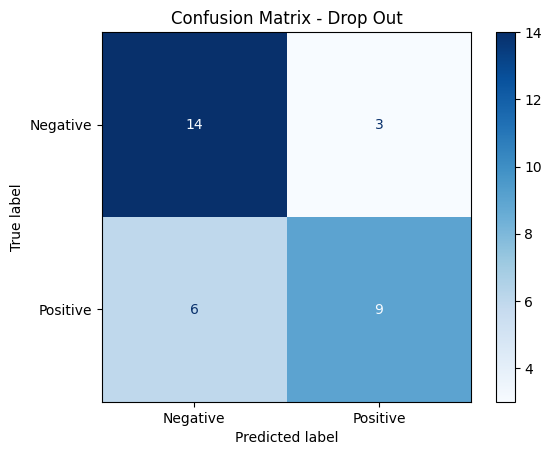


Drop Out Model:
True Positives: 9
False Positives: 3
True Negatives: 14
False Negatives: 6
Accuracy: 0.72
Precision: 0.75
Recall: 0.60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


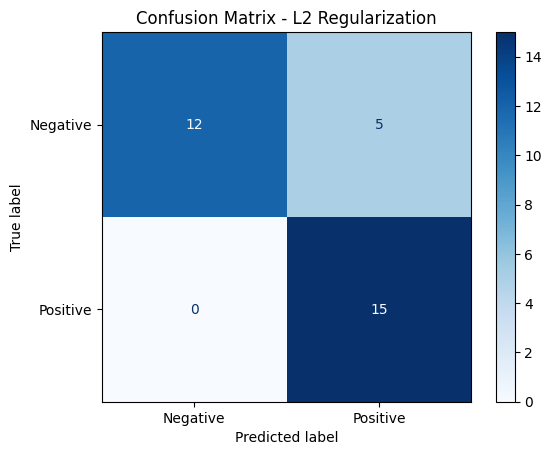


L2 Regularization Model:
True Positives: 15
False Positives: 5
True Negatives: 12
False Negatives: 0
Accuracy: 0.84
Precision: 0.75
Recall: 1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


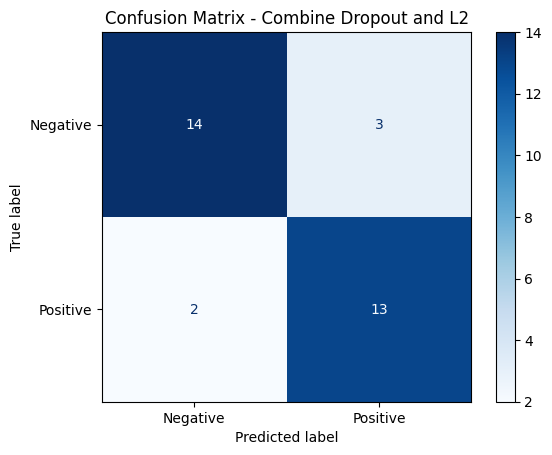


Combine Dropout and L2 Model:
True Positives: 13
False Positives: 3
True Negatives: 14
False Negatives: 2
Accuracy: 0.84
Precision: 0.81
Recall: 0.87
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


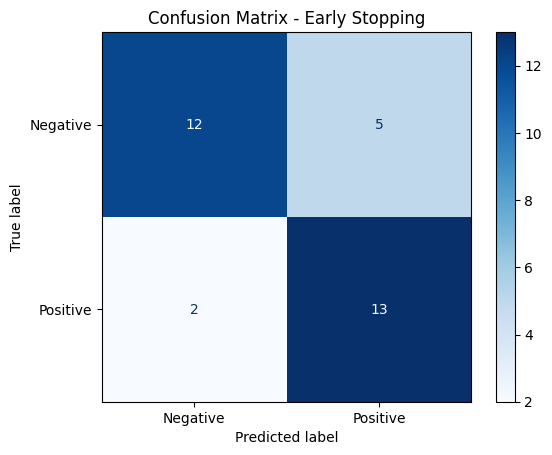


Early Stopping Model:
True Positives: 13
False Positives: 5
True Negatives: 12
False Negatives: 2
Accuracy: 0.78
Precision: 0.72
Recall: 0.87
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


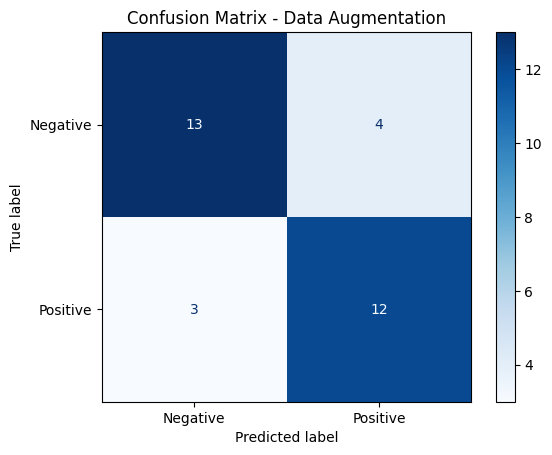


Data Augmentation Model:
True Positives: 12
False Positives: 4
True Negatives: 13
False Negatives: 3
Accuracy: 0.78
Precision: 0.75
Recall: 0.80


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load your saved models (you'll need to replace these with your actual models)
models = {
    'Base': model_basic,
    'Drop Out':model_dropout,
    'L2 Regularization':model_l2,
    "Combine Dropout and L2":model_dropout_l2,
    'Early Stopping':model_earlystopping,
    'Data Augmentation':model_basic_aug
}


# Get validation data and labels
val_images, val_labels = next((x for x in val_generator))

# For each model
for model_name, model in models.items():
    # Make predictions
    predictions = model.predict(val_images)
    predicted_classes = (predictions > 0.5).astype("int32")

    # Generate confusion matrix
    cm = confusion_matrix(val_labels, predicted_classes)

    # Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # Print metrics
    tn, fp, fn, tp = cm.ravel()
    print(f'\n{model_name} Model:')
    print(f'True Positives: {tp}')
    print(f'False Positives: {fp}')
    print(f'True Negatives: {tn}')
    print(f'False Negatives: {fn}')
    print(f'Accuracy: {(tp+tn)/(tp+tn+fp+fn):.2f}')
    print(f'Precision: {tp/(tp+fp):.2f}' if (tp+fp) > 0 else 'Precision: N/A')
    print(f'Recall: {tp/(tp+fn):.2f}' if (tp+fn) > 0 else 'Recall: N/A')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


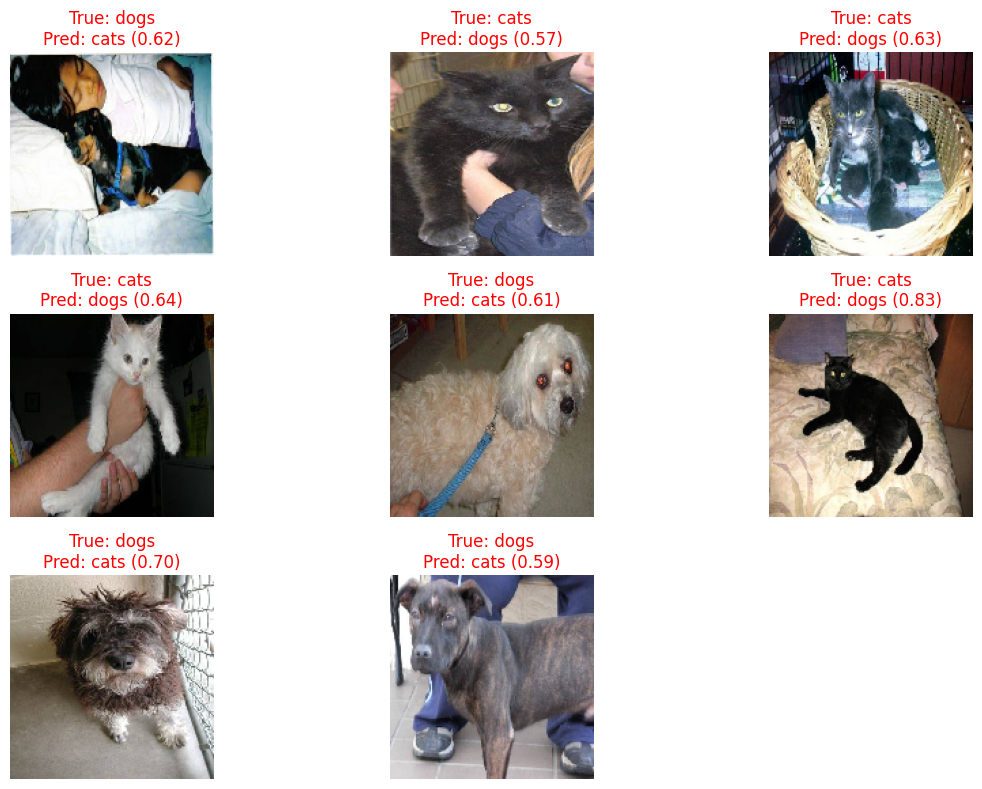

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of validation data
val_images, val_labels = next(val_generator)
val_preds = model_basic_aug.predict(val_images)

# Get class names (assuming binary classification)
class_names = list(val_generator.class_indices.keys())

# Find misclassified samples
val_pred_classes = (val_preds > 0.5).flatten().astype(int)
misclassified = np.where(val_pred_classes != val_labels)[0]

# Display up to 9 misclassified images
plt.figure(figsize=(12, 8))
for i, idx in enumerate(misclassified[:9]):
    plt.subplot(3, 3, i+1)
    plt.imshow(val_images[idx])

    true_label = class_names[int(val_labels[idx])]
    pred_label = class_names[val_pred_classes[idx]]
    confidence = val_preds[idx][0] if val_pred_classes[idx] == 1 else 1 - val_preds[idx][0]

    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

Plot

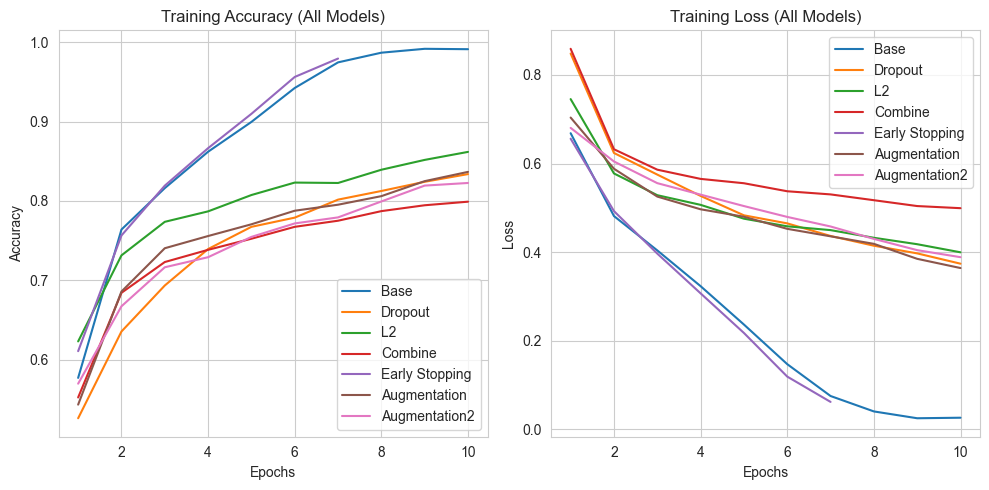

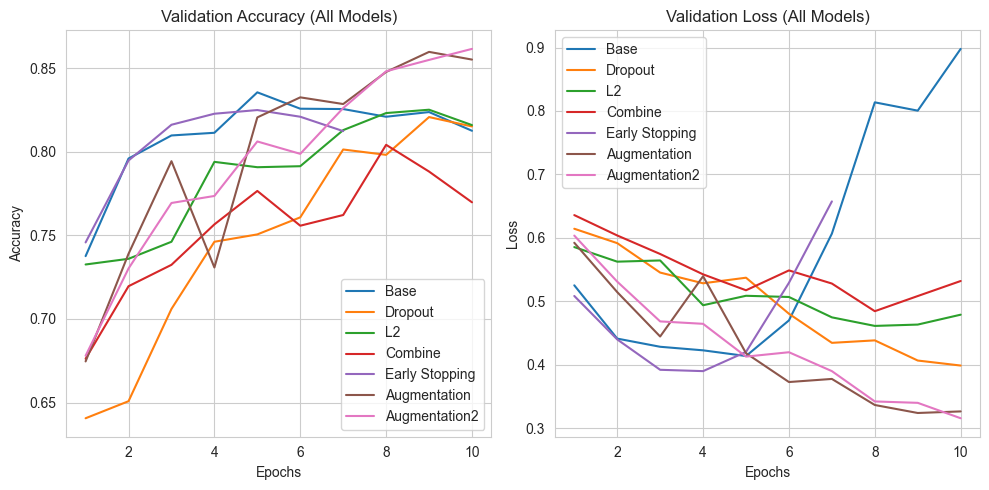

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and prepare data
df = pd.read_csv('output.csv', sep=';')
models = df['Model'].unique()

# 1. TRAINING PLOT (All models)
plt.figure(figsize=(10, 5))

# Training Accuracy
plt.subplot(1, 2, 1)
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['accuracy'], label=model)
plt.title('Training Accuracy (All Models)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Training Loss
plt.subplot(1, 2, 2)
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['loss'], label=model)
plt.title('Training Loss (All Models)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 2. VALIDATION PLOT (All models)
plt.figure(figsize=(10, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['val_accuracy'], label=model)
plt.title('Validation Accuracy (All Models)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Validation Loss
plt.subplot(1, 2, 2)
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['val_loss'], label=model)
plt.title('Validation Loss (All Models)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

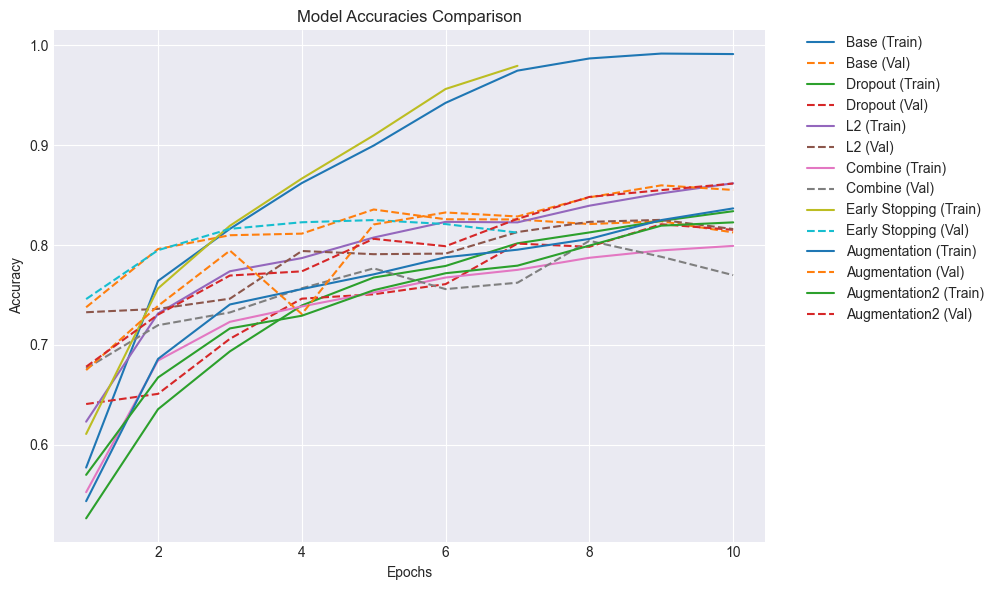

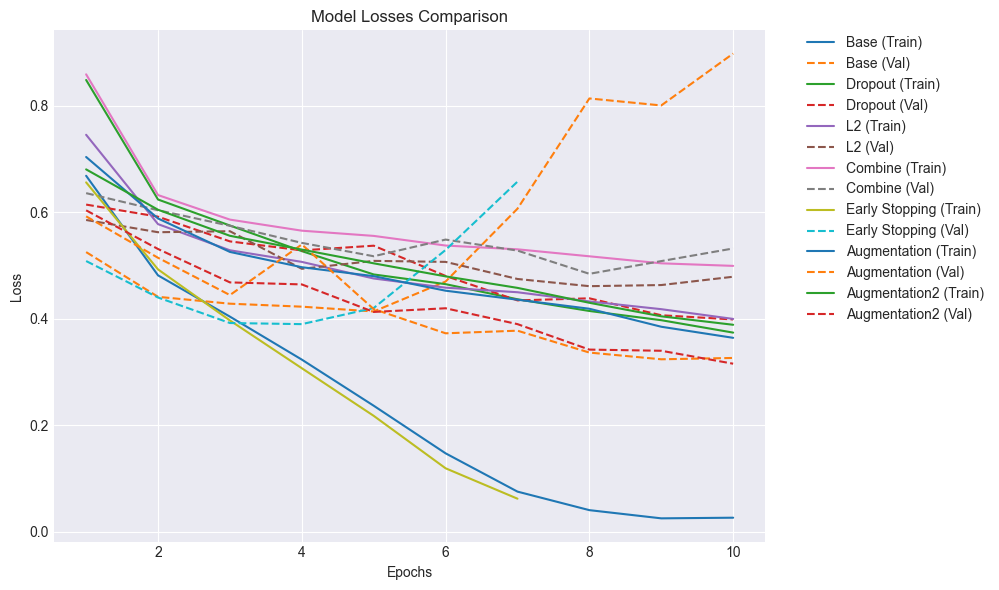

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
# Make sure 'output.csv' is in the same directory as your script,
# or provide the full path to the file.
try:
    df = pd.read_csv('output.csv', sep=';')
except FileNotFoundError:
    print("Error: 'output.csv' not found. Please check the file path.")
    exit()

models = df['Model'].unique()

# Set style
# Using a specific and available seaborn-like style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    print("Warning: 'seaborn-v0_8-darkgrid' style not found. Using default style.")
    # You can list available styles if you want to see options:
    # print("Available styles:", plt.style.available)

plt.rcParams['figure.figsize'] = [12, 6]

# 1. ALL ACCURACIES PLOT (Training + Validation)
plt.figure()
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['accuracy'],
             label=f'{model} (Train)', linestyle='-')
    plt.plot(model_data['Epoch'], model_data['val_accuracy'],
             label=f'{model} (Val)', linestyle='--')
plt.title('Model Accuracies Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
# Adjust legend position to avoid overlap if many models
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()

# 2. ALL LOSSES PLOT (Training + Validation)
plt.figure()
for model in models:
    model_data = df[df['Model'] == model]
    plt.plot(model_data['Epoch'], model_data['loss'],
             label=f'{model} (Train)', linestyle='-')
    plt.plot(model_data['Epoch'], model_data['val_loss'],
             label=f'{model} (Val)', linestyle='--')
plt.title('Model Losses Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# Adjust legend position
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()
